In [ ]:
from google.colab import drive
import os

# Mount drive
drive.mount('/content/drive')


Mounted at /content/drive


🔄 Reading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
🔄 Reading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
🔄 Reading: Friday-WorkingHours-Morning.pcap_ISCX.csv
🔄 Reading: Monday-WorkingHours.pcap_ISCX.csv
🔄 Reading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
🔄 Reading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
🔄 Reading: Tuesday-WorkingHours.pcap_ISCX.csv
🔄 Reading: Wednesday-workingHours.pcap_ISCX.csv
✅ Original label classes:
 Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Inj

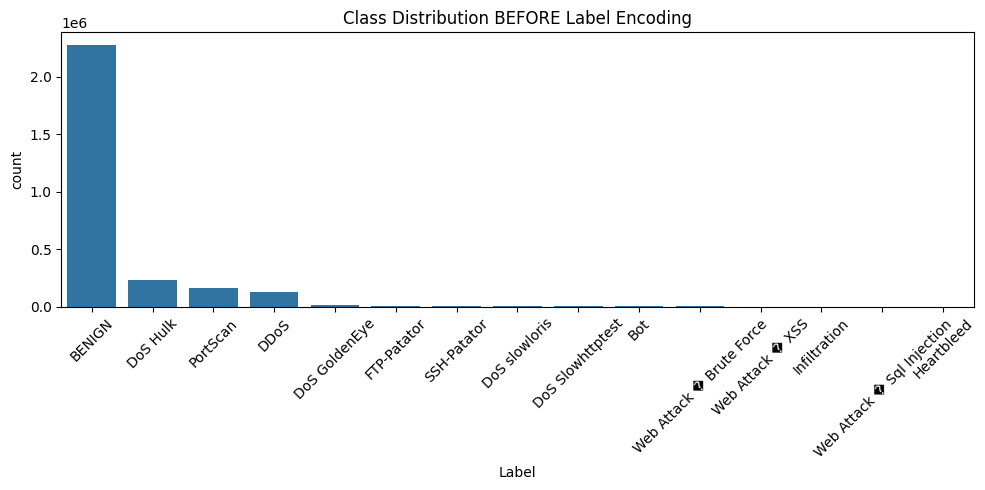


✅ Label Encoding Mapping:
BENIGN --> 0
Bot --> 1
DDoS --> 2
DoS GoldenEye --> 3
DoS Hulk --> 4
DoS Slowhttptest --> 5
DoS slowloris --> 6
FTP-Patator --> 7
Heartbleed --> 8
Infiltration --> 9
PortScan --> 10
SSH-Patator --> 11
Web Attack � Brute Force --> 12
Web Attack � Sql Injection --> 13
Web Attack � XSS --> 14


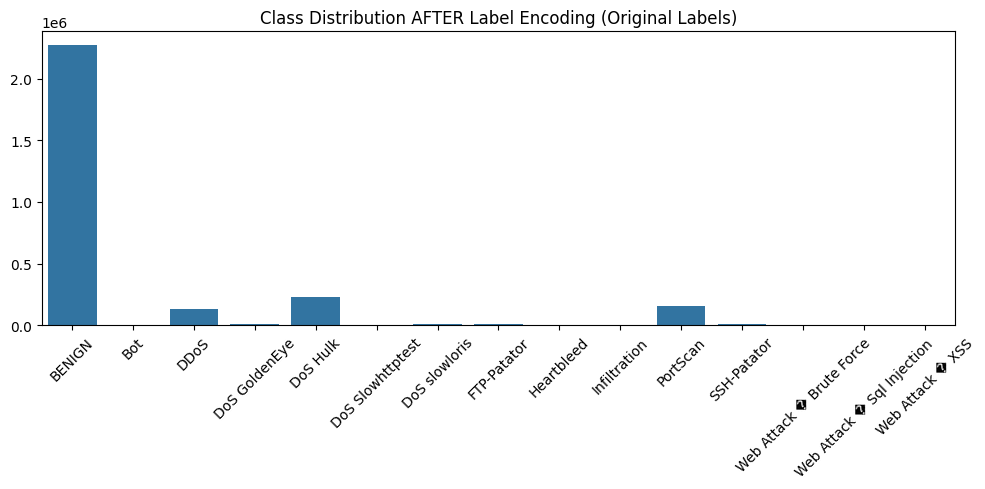

✅ Dataset shape AFTER preprocessing: (2827876, 79)

📌 Column types after cleanup:
 Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                            int64
Length: 79, dtype: object


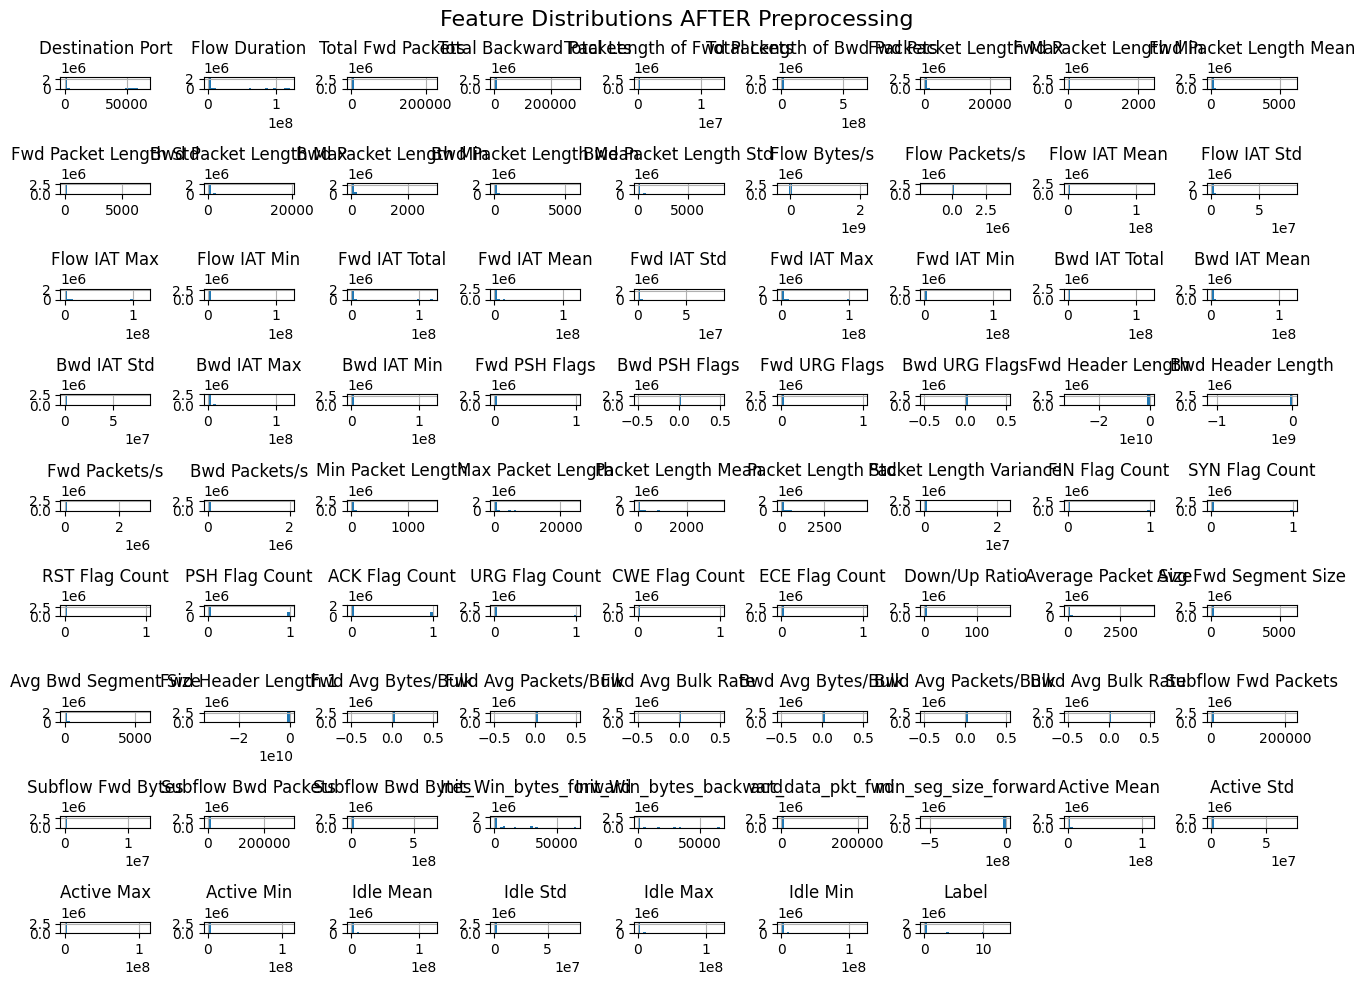

✅ PCA applied. Feature shape: (2827876, 30)
✅ Labels shape: (2827876,)


In [ ]:
# STEP 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Path to folder containing all CSV files
data_folder = "/content/drive/MyDrive/PROJECT/DATA SETS/CICIDS2017" # Corrected path

# Read and concatenate all CSV files from the folder
dataframes = []

for filename in os.listdir(data_folder):
    if filename.endswith(".csv"):
        file_path = os.path.join(data_folder, filename)
        print(f"🔄 Reading: {filename}")
        df = pd.read_csv(file_path, low_memory=False)
        dataframes.append(df)

# Combine all data
if dataframes: # Check if dataframes list is not empty
    df = pd.concat(dataframes, ignore_index=True)

    # Clean column names and drop irrelevant ones
    df.columns = df.columns.str.strip()
    df.drop(columns=['Flow ID', 'Source IP', 'Destination IP', 'Timestamp'], errors='ignore', inplace=True)

    # Handle infinite and missing values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    # Label encoding with visualization
    if 'Label' in df.columns:
        print("✅ Original label classes:\n", df['Label'].value_counts())

        # BEFORE Encoding
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x='Label', order=df['Label'].value_counts().index)
        plt.xticks(rotation=45)
        plt.title("Class Distribution BEFORE Label Encoding")
        plt.tight_layout()
        plt.show()

        # Label Encoding
        label_encoder = LabelEncoder()
        df['Label'] = label_encoder.fit_transform(df['Label'])

        # Mapping
        label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
        print("\n✅ Label Encoding Mapping:")
        for label, encoded in label_mapping.items():
            print(f"{label} --> {encoded}")

        # AFTER Encoding
        plt.figure(figsize=(10, 5))
        encoded_counts = df['Label'].value_counts().sort_index()
        original_labels_ordered = [label_encoder.classes_[i] for i in encoded_counts.index]
        sns.barplot(x=original_labels_ordered, y=encoded_counts.values)
        plt.xticks(rotation=45)
        plt.title("Class Distribution AFTER Label Encoding (Original Labels)")
        plt.tight_layout()
        plt.show()
    else:
        print("❌ 'Label' column not found in dataset!")

    # STEP 5: Summary of cleaned dataset
    print("✅ Dataset shape AFTER preprocessing:", df.shape)
    print("\n📌 Column types after cleanup:\n", df.dtypes)

    # STEP 6: Visualize all numeric features
    df.select_dtypes(include='number').hist(figsize=(13, 10), bins=30)
    plt.suptitle("Feature Distributions AFTER Preprocessing", fontsize=16)
    plt.tight_layout()
    plt.show()

    # STEP 7: Feature scaling and PCA
    X = df.drop('Label', axis=1)
    y = df['Label']

    # Standard scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA transformation (you can tune n_components if needed)
    pca = PCA(n_components=30)
    X_pca = pca.fit_transform(X_scaled)

    # Final output shapes
    print("✅ PCA applied. Feature shape:", X_pca.shape)
    print("✅ Labels shape:", y.shape)
else:
    print(f"❌ No CSV files found in the directory: {data_folder}")

In [ ]:
# Reshape for CNN
X_reshaped = X_pca.reshape(X_pca.shape[0], X_pca.shape[1], 1)

NameError: name 'X_pca' is not defined

In [ ]:
# One-hot encode target
from tensorflow.keras.utils import to_categorical
y_cat = to_categorical(y)

In [ ]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

In [ ]:
# ✅ Required Imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Dense, LSTM, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# ✅ Build the model
model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_reshaped.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.4),

    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.4),

    Dense(y_cat.shape[1], activation='softmax')  # Use 'y_cat' if you already one-hot encoded your labels
])

# ✅ Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ✅ Train the model
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=2
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
15907/15907 - 401s - 25ms/step - accuracy: 0.9497 - loss: 0.1517 - val_accuracy: 0.9701 - val_loss: 0.0736
Epoch 2/15
15907/15907 - 378s - 24ms/step - accuracy: 0.9671 - loss: 0.0854 - val_accuracy: 0.9733 - val_loss: 0.0625
Epoch 3/15
15907/15907 - 370s - 23ms/step - accuracy: 0.9700 - loss: 0.0754 - val_accuracy: 0.9747 - val_loss: 0.0588
Epoch 4/15
15907/15907 - 399s - 25ms/step - accuracy: 0.9716 - loss: 0.0706 - val_accuracy: 0.9751 - val_loss: 0.0558
Epoch 5/15
15907/15907 - 364s - 23ms/step - accuracy: 0.9728 - loss: 0.0677 - val_accuracy: 0.9764 - val_loss: 0.0536
Epoch 6/15
15907/15907 - 366s - 23ms/step - accuracy: 0.9738 - loss: 0.0653 - val_accuracy: 0.9784 - val_loss: 0.0525
Epoch 7/15
15907/15907 - 434s - 27ms/step - accuracy: 0.9743 - loss: 0.0635 - val_accuracy: 0.9766 - val_loss: 0.0520
Epoch 8/15
15907/15907 - 379s - 24ms/step - accuracy: 0.9746 - loss: 0.0621 - val_accuracy: 0.9766 - val_loss: 0.0511
Epoch 9/15
15907/15907 - 387s - 24ms/step - accuracy: 0.

In [ ]:
# Evaluate
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
from __main__ import label_encoder

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(f"Test Accuracy: {accuracy_score(y_true, y_pred_classes)*100:.2f}%")
print(classification_report(y_true, y_pred_classes, target_names=label_encoder.classes_))

17675/17675 ━━━━━━━━━━━━━━━━━━━━ 93s 5ms/step
Test Accuracy: 97.89%
                            precision    recall  f1-score   support

                    BENIGN       0.98      0.99      0.99    454265
                       Bot       0.92      0.37      0.53       391
                      DDoS       1.00      0.98      0.99     25605
             DoS GoldenEye       0.97      0.94      0.96      2059
                  DoS Hulk       0.98      0.91      0.94     46025
          DoS Slowhttptest       0.86      0.91      0.88      1100
             DoS slowloris       0.94      0.94      0.94      1159
               FTP-Patator       0.89      0.98      0.93      1587
                Heartbleed       0.00      0.00      0.00         2
              Infiltration       0.00      0.00      0.00         7
                  PortScan       0.90      0.95      0.92     31761
               SSH-Patator       0.93      0.97      0.95      1180
  Web Attack � Brute Force       1.00      0.04

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


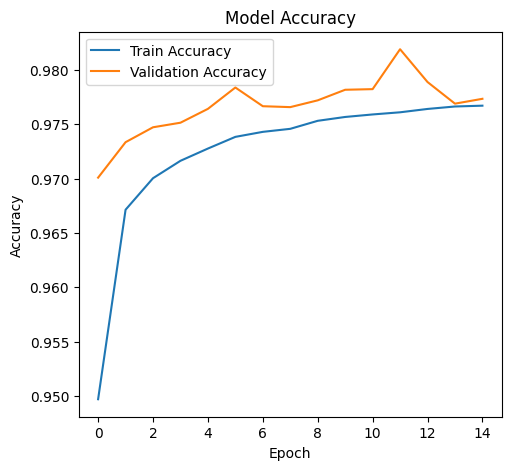

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


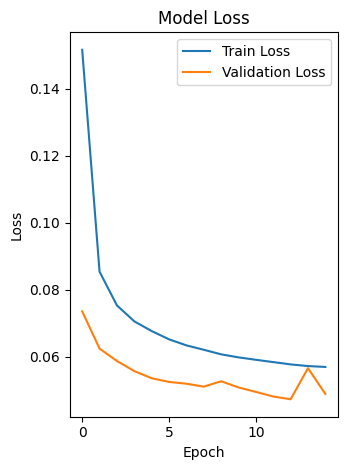

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

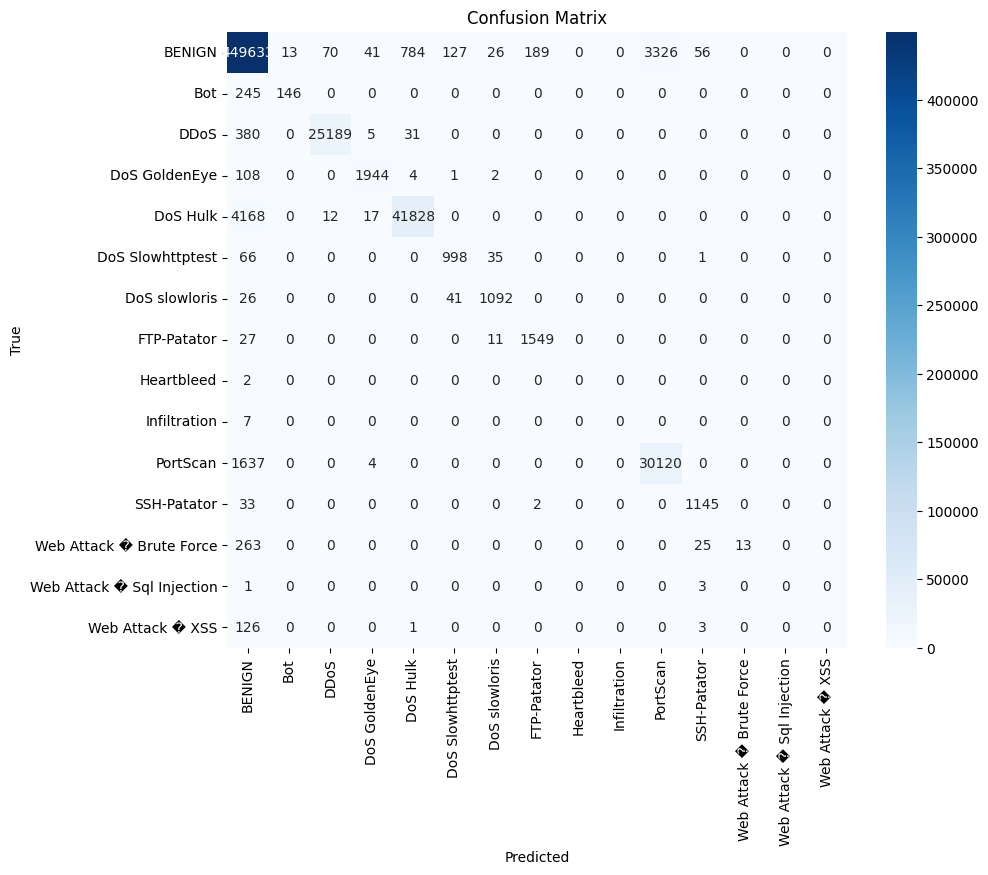

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import joblib
from google.colab import files

# Save model and preprocessing objects
model.save("model.h5")
joblib.dump(label_encoder, "label_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

# Download to your computer
files.download("model.h5")
files.download("label_encoder.pkl")
files.download("scaler.pkl")
files.download("pca.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>